In [16]:
import numpy as np 
import pandas as pd
import casadi as ca
import matplotlib.pyplot as plt

# Optimisation

**Anna Bergougnoux Santini et Julien Colella**  
Avril 2026  

---

1. Le revenu d'une entreprise s'écrit :  

   $$
   R(y)= p(y)y - c(y)
   $$

   Ici, la formule va de soi : on multiplie la matrice des quantités de matière première commandées $c=(c_i)$ avec la matrice coût unitaire $r=(r_i)$.

   $min(q,d)$ correspond à la quantité vendue :  
   - si $q > d$, comme on ne peut pas vendre plus que la demande, la quantité vendue est donc $d$  
   - si $q < d$, on vend une quantité $q$

2. Ce terme-ci n'est pas différentiable.

3. Soit $\alpha \gg 1$ :
$$h_i(q, d) = \frac{q_i e^{-\alpha q_i} + d_i e^{-\alpha d_i}}{e^{-\alpha q_i} + e^{-\alpha d_i}}$$

Sans perte de généralité, supposons $q_i \leq d_i$. Alors pour $\alpha \gg 1$ :

$$e^{-\alpha d_i} \ll e^{-\alpha q_i}$$

En divisant numérateur et dénominateur par $e^{-\alpha q_i}$ :

$$h_i(q, d) = \frac{q_i + d_i e^{-\alpha(d_i - q_i)}}{1 + e^{-\alpha(d_i - q_i)}} \xrightarrow{\alpha \to +\infty} \frac{q_i + 0}{1 + 0} = q_i = \min(q_i, d_i)$$

Donc pour $\alpha \gg 1$, $h_i(q,d) \approx \min(q_i, d_i)$, et $h$ est une bonne approximation 
composante par composante de la fonction $\min$.

4. On cherche alors à minimiser :

   $$
   g(q,d) = - v^T h(q, d) + c^T r
   $$

   sous la contrainte :

   $$
   Aq - r \le 0
   $$

   On peut donc réécrire ceci avec $z=(q,r)$ :

   $$
   g(z) = - v^T h(z_1, d) + c^T z_2
   $$

Ainsi que :

   $$
   c(z) = (A z_1 - z_2, - z_1, -z_2)
   $$

   $z$ dépend donc des deux vecteurs $q$ et $r$, et donc des $q_j$ et des $r_i$.




5. Pour ce problème, qui est donc un problème d'optimisation sous contrainte, où $f$ est différentiable non-linéaire et $c$ est une contrainte linéaire, on peut penser aux conditions de KKT.



**Question 6**

In [17]:
alpha = 0.1
c = 1e-3 * np.array([30,1,1.3,4,1])
v = np.array([0.9,1.5,1.1])
d = np.array([400,67,33])
A = np.array([
    [3.5,2,1],
    [250,80,25],
    [0,8,3],
    [0,40,10],
    [0,8.5,0]
])

m = 5
p = 3

c = ca.DM(c)
v = ca.DM(v)
#on a eu un problème avec les multiplications entre array et objets casadi, 
#on a donc converti les array de facon à ce que les ojets manipulés soient compatibles

r = ca.MX.sym('r', m)
q = ca.MX.sym('q', p)


def h(q, d, alpha):
    return (q*ca.exp(-alpha*q) + d*ca.exp(-alpha*d)) / (ca.exp(-alpha*q) + ca.exp(-alpha*d))

f = c.T @ r - v.T @ h(q, d, alpha)


#contraintes
c1 = A @ q - r
c2 = -r
c3 = -q

c = ca.vertcat(c1, c2, c3)


nlp = {'x': ca.vertcat(r,q), 'f': f, 'g': c}

solver = ca.nlpsol('solver', 'ipopt', nlp)


sol = solver(lbg=-ca.inf, ubg=0)

z_opt = sol['x']
print(z_opt)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:       28
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        8
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:       13
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       13

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -1.4147887e+00 0.00e+00 1.14e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

Les résultats sont conformes à l'intuition : on commande juste assez pour satisfaire la demande avec un peu de marge, et on maximise ainsi la quantité vendue.

**Question 7**

*Question 7.a*

On souhaite maximiser l'**espérance** du revenu (3) :

$$\max_{q \geq 0,\, r \geq 0} \; \mathbb{E}\left[ v^T h(q, d) - c^T r \right] = \max_{q \geq 0,\, r \geq 0} \sum_{k=1}^{K} \pi^k \left( v^T h(q, d^k) - c^T r \right)$$

Puisque $r$ ne dépend pas du scénario, on peut factoriser :

$$\max_{q \geq 0,\, r \geq 0} \; \sum_{k=1}^{K} \pi^k \, v^T h(q, d^k) \;-\; c^T r$$

d'où le problème

$$\boxed{\max_{q \geq 0,\, r \geq 0} \; \sum_{k=1}^{K} \pi^k \, v^T h(q, d^k) - c^T r}$$

sous la contrainte :

$$r \geq Aq$$

où $h_i(q, d^k) = \dfrac{q_i e^{-\alpha q_i} + d^k_i e^{-\alpha d^k_i}}{e^{-\alpha q_i} + e^{-\alpha d^k_i}}$ est l'approximation du $\min$.

On peut aussi formuler ce problème comme un problème de minimisatiion, mais l'énoncé spécifie qu'on cherche à maximiser l'espérance du coût. Nous avons donc laissé cette formulation-ci.

*Question 7.b*

In [19]:
alpha = 0.1
c = 1e-3 * np.array([30,1,1.3,4,1])
v = np.array([0.9,1.5,1.1])
d1 = np.array([400,67,33])
d2 = np.array([500,80,53])
d3 = np.array([300,60,43])
A = np.array([
    [3.5,2,1],
    [250,80,25],
    [0,8,3],
    [0,40,10],
    [0,8.5,0]
])

m = 5
p = 3

def h(q, d, alpha):
    return (q*ca.exp(-alpha*q) + d*ca.exp(-alpha*d)) / (ca.exp(-alpha*q) + ca.exp(-alpha*d))

c = ca.DM(c)
v = ca.DM(v)
#on a eu un problème avec les multiplications entre array et objets casadi, 
#on a donc converti les array de facon à ce que les ojets manipulés soient compatibl    es

q = ca.MX.sym('q', p)
r= ca.MX.sym('r', m)

f = c.T @ r - 0.5*v.T @ h(q, d1, alpha) - 0.3*v.T @ h(q, d2, alpha) - 0.2*v.T @ h(q, d3, alpha)


#contraintes
c1= -q 
c2 = -r
c3= A @ q - r

c = ca.vertcat(c1, c2, c3)


nlp = {'x': ca.vertcat(q, r), 'f': f, 'g': c}

solver = ca.nlpsol('solver', 'ipopt', nlp)


sol = solver(lbg=-ca.inf, ubg=0)

z_opt_h = sol['x']
print(z_opt_h)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:       28
Number of nonzeros in Lagrangian Hessian.............:        3

Total number of variables............................:        8
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:       13
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       13

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -9.7748379e-01 0.00e+00 1.13e+00  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [20]:
# rendement de la solution avec h
cost = ca.DM(1e-3 * np.array([30,1,1.3,4,1]))
def f(q, r):
    return cost.T @ r - 0.5*v.T @ h(q, d1, alpha) - 0.3*v.T @ h(q, d2, alpha) - 0.2*v.T @ h(q, d3, alpha)

q_opt_h= z_opt_h[:p]
r_opt_h = z_opt_h[p:]
print("q_opt:", q_opt_h)
print("r_opt:", r_opt_h)
print("espérence de revenu optimale:", -f(q_opt_h, r_opt_h))

q_opt: [406.698, 77.1392, 54.2896]
r_opt: [1632.01, 109203, 779.982, 3628.46, 655.683]
espérence de revenu optimale: 323.96


**Question 8**
 

*Question 8.a*

 On cherche à maximiser l'espérance du revenu :

$$\max_{q \geq 0,\, r \geq 0} \quad \sum_{k=1}^K \pi^k \, v^T \min(q, d^k) - c^T r$$

$$\text{s.c.} \quad r \geq Aq$$


*Question 8.b*


On considère la fonction coût non-approchée (2) avec $K$ scénarios de demande $d^k$ de probabilités $\pi^k$.
On cherche à maximiser l'espérance du revenu :

$$\max_{q \geq 0,\, r \geq 0} \quad \sum_{k=1}^K \pi^k \, v^T \min(q, d^k) - c^T r$$

$$\text{s.c.} \quad r \geq Aq$$


On réécrit le problème sous forme de minimisation :

$$\min_{q \geq 0,\, r} \quad c^T r - \sum_{k=1}^K \pi^k \, v^T \min(q, d^k) \quad \text{s.c.} \quad Aq - r \leq 0$$

Le Lagrangien associé est :

$$\mathcal{L}(q, r, \lambda) = c^T r - \sum_{k=1}^K \pi^k \, v^T \min(q, d^k) + \lambda^T(Aq - r)$$

La condition KKT sur $r$ (le Lagrangien est lisse en $r$) donne :

$$\frac{\partial \mathcal{L}}{\partial r} = c - \lambda = 0 \implies \lambda = c$$

Or $c > 0$ par hypothèse (coûts strictement positifs). La condition de complémentarité KKT impose :

$$\lambda_i \cdot \left[(Aq)_i - r_i\right] = 0 \quad \forall i$$

Comme $\lambda_i = c_i > 0$, on conclut nécessairement :

$$r_i = (Aq)_i \quad \forall i \quad \Rightarrow \quad r = Aq$$

La contrainte (1) est donc active à l'optimum.

*Question 8.c*

On remplace donc r par Aq et on cherche à maximiser la quantité :

$$\boxed{\sum_{k=1}^{K} \pi^k \, v^T h(q, d^k) - c^T Aq}$$




**Question 9**

*Question 9.a*

On veut montrer que maximiser $v^T \min(q, d^k)$ est équivalent à maximiser $v^T u^k$ sous les contraintes $u^k \leq q$ et $u^k \leq d^k$, pour $u^k \in \mathbb{R}^p$.

=> Soit $u^k = \min(q, d^k)$ (le minimum composante par composante). Par définition :

$$u^k_j = \min(q_j, d^k_j) \leq q_j \quad \text{et} \quad u^k_j \leq d^k_j \quad \forall j$$

Donc $u^k = \min(q, d^k)$ est admissible, et atteint la valeur $v^T \min(q, d^k)$.

<= Pour tout $u^k$ admissible (i.e. $u^k \leq q$ et $u^k \leq d^k$), on a composante par composante :

$$u^k_j \leq \min(q_j, d^k_j) \quad \forall j$$

Comme $v \geq 0$, on en déduit :

$$v^T u^k \leq v^T \min(q, d^k)$$

Le maximum de $v^T u^k$ sur l'ensemble admissible est donc atteint en $u^k = \min(q, d^k)$, et vaut exactement $v^T \min(q, d^k)$.


*Question 9.b*

Le problème se reformule : 

$$\max_{0 \geq u^k - q,\, 0 \geq u^k - d^k} \; \sum_{k=1}^{K} \pi^k \, v^Tu^k \;-\; c^T Aq$$

L'intérêt principal est de s'être débarrassé du minimum dans le problème, est donc de s'être ramené à un cas lisse.

*Question 9.c*


In [21]:
alpha = 0.1
c = 1e-3 * np.array([30,1,1.3,4,1])
v = np.array([0.9,1.5,1.1])
d1 = np.array([400,67,33])
d2 = np.array([500,80,53])
d3 = np.array([300,60,43])
A = np.array([
    [3.5,2,1],
    [250,80,25],
    [0,8,3],
    [0,40,10],
    [0,8.5,0]
])

m = 5
p = 3

c = ca.DM(c)
v = ca.DM(v)
#on a eu un problème avec les multiplications entre array et objets casadi, 
#on a donc converti les array de facon à ce que les ojets manipulés soient compatibles

q = ca.MX.sym('q', p)
u1 = ca.MX.sym('u1', p)
u2 = ca.MX.sym('u2', p)
u3 = ca.MX.sym('u3', p)

f = c.T @ A@ q - 0.5*v.T @ u1-0.3*v.T @ u2 - 0.2*v.T @ u3


#contraintes
c1= -q + u1
c2 = -q + u2
c3 = -q + u3
c4 = -d1 + u1
c5 = -d2 + u2
c6 = -d3 + u3

c = ca.vertcat(c1, c2, c3, c4, c5, c6)


nlp = {'x': ca.vertcat(q, u1, u2, u3), 'f': f, 'g': c}

solver = ca.nlpsol('solver', 'ipopt', nlp)


sol = solver(lbg=-ca.inf, ubg=0)

z_opt = sol['x']
print(z_opt)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:       27
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:       12
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:       18
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       18

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  0.0000000e+00 0.00e+00 8.75e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [25]:
# rendement de la solution avec u
cost = ca.DM(1e-3 * np.array([30,1,1.3,4,1]))
def f(q, u1, u2, u3):
    return cost.T @ A@q - 0.5*v.T @ u1 - 0.3*v.T @ u2 - 0.2*v.T @ u3

q_opt_u= z_opt[:p]
u1_opt_u = z_opt[p:2*p]
u2_opt_u = z_opt[2*p:3*p]
u3_opt_u = z_opt[3*p:4*p]

print("q_opt:", q_opt_u)
print("u1_opt:", u1_opt_u)
print("u2_opt:", u2_opt_u)
print("u3_opt:", u3_opt_u)

print("espérance de revenu optimale:", -f(q_opt_u, u1_opt_u, u2_opt_u, u3_opt_u), "€")

q_opt: [400, 80, 53]
u1_opt: [400, 67, 33]
u2_opt: [400, 80, 53]
u3_opt: [300, 60, 43]
espérance de revenu optimale: 318.596 €


**Question 10**

*Question 10.a*

On peut penser à la méthode des sous-gradients

*Question 10.b*

=== Q10 — Méthode par sous-gradient ===
q* = [372.56  80.    53.  ]
r* = [  1516.95 100864.63    798.99   3729.96    679.99]
Revenu espéré = 308.5800 €


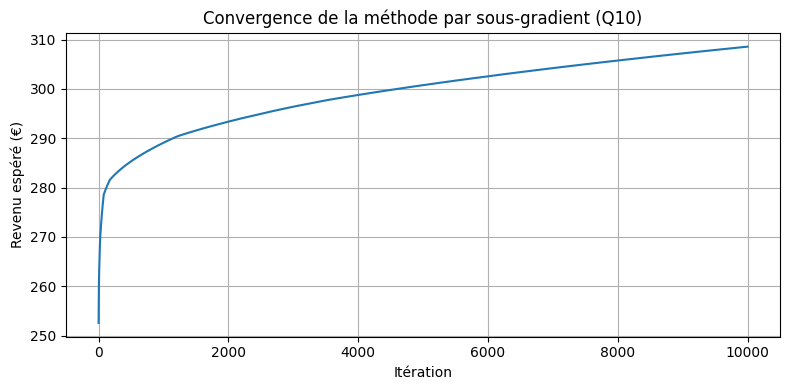

In [28]:
import numpy as np
import matplotlib.pyplot as plt


c_vec = 1e-3 * np.array([30,1,1.3,4,1])
v_vec = np.array([0.9,1.5,1.1])
D = np.array([[400,67,33],[500,80,53],[300,60,43]], dtype=float)
pi = np.array([0.5, 0.3, 0.2])
A = np.array([[3.5,2,1],[250,80,25],[0,8,3],[0,40,10],[0,8.5,0]])

p = 3

def objectif(q):
    rev = sum(pi[k] * v_vec @ np.minimum(q, D[k]) for k in range(3))
    return rev - c_vec @ (A @ q)


def sous_gradient(q):
    grad = -A.T @ c_vec  # partie lisse
    for k in range(3):
        sg = np.where(q < D[k], 1.0, np.where(q > D[k], 0.0, 0.5))
        grad += pi[k] * v_vec * sg
    return grad

pas = 1.0
n_iter = 10000
q = np.array([300., 50., 30.])
best_q = q.copy()
best_val = objectif(q)
history = [best_val]

for t in range(1, n_iter + 1):
    sg = sous_gradient(q)
    q = q + (pas / np.sqrt(t)) * sg  
    q = np.maximum(q, 0)             
    
    val = objectif(q)
    if val > best_val:
        best_val = val
        best_q = q.copy()
    history.append(best_val)

print("=== Q10 — Méthode par sous-gradient ===")
print(f"q* = {np.round(best_q, 2)}")
print(f"r* = {np.round(A @ best_q, 2)}")
print(f"Revenu espéré = {best_val:.4f} €")

# graphe
plt.figure(figsize=(8,4))
plt.plot(history)
plt.xlabel("Itération")
plt.ylabel("Revenu espéré (€)")
plt.title("Convergence de la méthode par sous-gradient (Q10)")
plt.grid(True)
plt.tight_layout()
plt.show()

Note : nous nous sommes servis de l'IA pour la conversion de nos notes manuscrites en markdown, car ni l'un ni l'autre ne connaissions la syntaxe exacte ; ainsi que pour les technicités de la bibliothèque casadi. La question 10.b nous ayant posé un petit problème de structure de code, nous avons eu recours à un assistant de code. 